In [42]:
#!pip install rasterio
#!pip install "numpy<2"

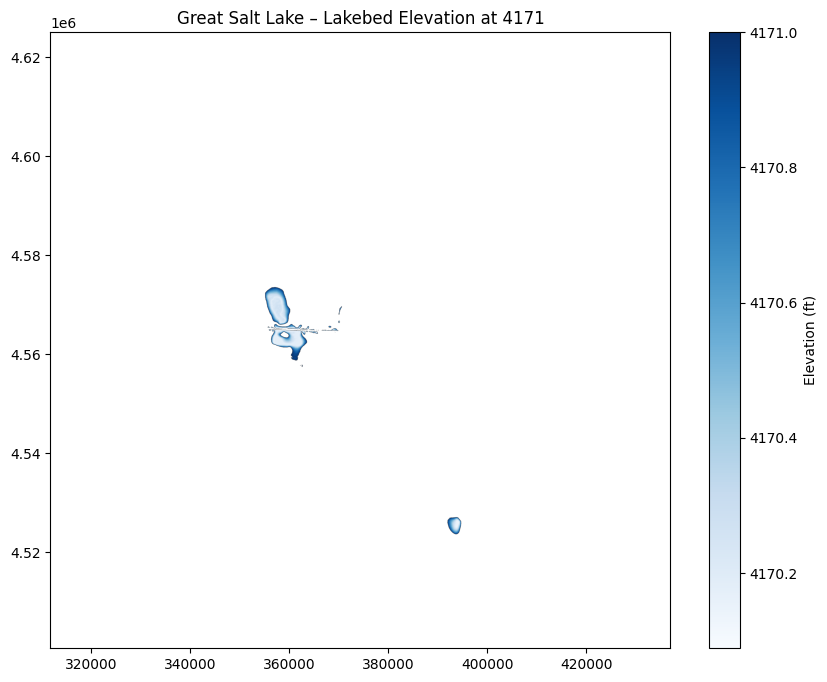

In [40]:
"""
Created on Thu Jan 29 22:30:43 2026

@author: matt
"""
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import Affine


# not yet not smart enough for this shit
#Matt's code but shrunken for memory
def disp_fig(level = 4188, step = 4):
    npy_path = "great_salt_lake_downsampled_with_meta.npz"
    ds_dat = np.load(npy_path)
    data = ds_dat["data"]
    transform = ds_dat["transform"]
    crs = ds_dat["crs"]
        
    affine = Affine(
        transform[1], transform[2], transform[0],
        transform[4], transform[5], transform[3])
    
    lake = data.astype(np.float32)          # fix #2: float32 instead of float64
    
    lake[lake == 0] = np.nan
    lake[lake > level] = np.nan
    
    lake = lake[::step, ::step]
    
    nrows, ncols = lake.shape
    cols = np.arange(0, ncols * step, step)   # scaled back up so spacing stays correct
    rows = np.arange(0, nrows * step, step)
    
    x = affine.c + cols * affine.a            # fix #1: 1D vectors, no meshgrid
    y = affine.f + rows * affine.e
    
    plt.figure(figsize=(10, 8))
    
    # fix #3: imshow instead of contourf
    extent = [x.min(), x.max(), y.min(), y.max()]
    cf = plt.imshow(
        lake,
        extent=extent,
        origin='upper' if y[0] > y[-1] else 'lower',
        cmap = 'Blues'
    )
    
    plt.colorbar(cf, label="Elevation (ft)")
    plt.title("Great Salt Lake – Lakebed Elevation at " + str(level))
    plt.axis("equal")
    
    plt.show()



if __name__ == "__main__":
    min_el = 4170
    max_el = 4200
    disp_fig(4171)
    
    
